# Multilevel Regression for Urban Performance Score

This notebook estimates multilevel regression models for `performance_score` using urban-form predictors. The main model separates **within-city** and **between-city** effects, which is usually essential for grid-level observations nested inside cities.

Main structure:

- Level 1: grid cells
- Level 2: cities
- Optional city-level fixed effect: city-size category
- Outcome: `performance_score`
- Predictors: urban-form features

In [34]:
# ========================= Imports and Settings =========================
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:.4f}".format
sns.set_theme(style="whitegrid")

OUT_DIR = "../output/multilevel_regression"
os.makedirs(OUT_DIR, exist_ok=True)

RANDOM_STATE = 42

## 1. Load Data

In [35]:
# Prefer the file that already contains performance_score.
DATA_PATH = "../data/grid500_performance_score.csv"

grid500 = pd.read_csv(DATA_PATH, index_col=0)
print(grid500.shape)
grid500.head()

(194941, 51)


,Global_ID,City,NTL2023,NTL2023_focal,VIT202311,UHIDAY2020_07_inv,buildingCount,totalHeight,avgHeight,maxHeight,minHeight,heightRange,heightIndex,heightDensity,heightOtherness,cornerCountTotal,basePerimeterTotal,basePerimeterAvg,basePerimeterMax,basePerimeterMin,shapeComplexity,compactness,footprintAreaTotal,totalArea,areaVariance,avgBuildingArea,parcelArea,largestPatchIndex,shape3DIndex,SVF,evennessIndex,FAR,coverageRatio,FVC,permeableRatio,poiDensity,poiDiversity,streetRatio,roadDensity,intersectionDensity,cornerCountAvg,buildingProximity,buildingMinDist,buildingMaxDist,buildingDistAvg,buildingDistVar,cluster_label,log_NTL2023_focal,log_VIT202311,distance_to_surface,performance_score
0,0,Beijing,6.1850,7.0300,1649.8571,0.4728,31,93.0000,3.0000,3.0000,3.0000,0.0000,0.0323,0.0004,0.0000,180,6500.9830,209.7091,831.6324,32.5533,5.0701,0.5614,88704.5751,88704.5751,50961857.7000,2861.4379,132998.2511,0.4670,0.0082,0.8024,234.6035,0.3548,0.3548,0.8366,0.8948,4.0000,0.0000,0.1994,5,1,5.8065,52.5611,14.9887,620.9377,268.0891,2565.5688,5.0000,0.3557,0.6654,0.2119,0.7542
1,1,Beijing,5.7400,7.2261,155.8571,0.4728,29,87.0000,3.0000,3.0000,3.0000,0.0000,0.0345,0.0003,0.0000,149,3810.3930,131.3929,272.1380,15.3292,5.1700,0.6206,33119.4905,33119.4905,1261729.8840,1142.0514,196625.2176,0.6683,0.2644,0.8906,35.6626,0.1325,0.1325,0.8570,0.9383,12.0000,0.6365,0.1994,7,1,5.1379,34.2211,6.8159,594.1575,300.0878,2010.8442,5.0000,0.3598,0.4540,0.3538,0.5893
2,2,Beijing,11.3200,13.6167,57.1429,0.4728,22,66.0000,3.0000,3.0000,3.0000,0.0000,0.0455,0.0003,0.0000,117,3645.3976,165.6999,668.2643,28.7300,4.9243,0.5589,51092.8628,51092.8628,30358745.8300,2322.4029,132197.3125,0.5288,0.0134,0.8982,151.4966,0.2044,0.2044,0.8818,0.9257,0.0000,0.0000,0.1994,1,0,5.3182,47.9015,17.3445,610.8432,283.8433,2044.7287,5.0000,0.4580,0.3649,0.4015,0.5339
3,3,Beijing,11.7300,14.3617,243.5714,0.4728,8,24.0000,3.0000,3.0000,3.0000,0.0000,0.1250,0.0001,0.0000,42,1147.5982,143.4498,283.0113,75.6611,5.7024,0.5969,8534.6141,8534.6141,958399.8878,1066.8268,205685.3683,0.8227,0.0179,0.9475,15.5408,0.0341,0.0341,0.9335,0.9785,0.0000,0.0000,0.1994,3,1,5.2500,35.9269,13.4894,474.1686,232.3126,1896.1434,5.0000,0.4665,0.4939,0.3050,0.6460
4,4,Beijing,8.4500,9.1900,0.0000,0.4728,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,99.1487,0.0004,0.0000,0.9777,0.0000,0.0000,0.0000,0.8153,0.9844,16.0000,0.6931,0.0000,1,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.3964,0.0000,0.6089,0.2930


In [36]:
target = "performance_score"
group_col = "City"

features = [
    'buildingCount', 'totalHeight', 'avgHeight', 'basePerimeterTotal',
    'basePerimeterAvg', 'compactness', 'footprintAreaTotal', 'totalArea',
    'avgBuildingArea', 'FAR', 'coverageRatio',
    'roadDensity', 'intersectionDensity', 'poiDensity', 'poiDiversity',
    'FVC', 'permeableRatio', 'maxHeight', 'minHeight', 'heightRange', 'heightIndex',
    'heightDensity', 'heightOtherness', 'cornerCountTotal', 'basePerimeterMax',
    'basePerimeterMin', 'shapeComplexity', 'areaVariance', 'parcelArea',
    'largestPatchIndex', 'shape3DIndex', 'evennessIndex', 'cornerCountAvg',
    'buildingProximity', 'buildingMinDist', 'buildingMaxDist',
    'buildingDistAvg', 'buildingDistVar', 'SVF', 'streetRatio'
]

required_cols = [target, group_col] + features
missing_cols = [c for c in required_cols if c not in grid500.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("Number of candidate features:", len(features))
print("Number of cities:", grid500[group_col].nunique())

Number of candidate features: 40
Number of cities: 36


## 2. Add City-Size Category

`City_Category` is included as a city-level fixed effect. If you do not want this adjustment, set `USE_CITY_CATEGORY = False`.

In [37]:
USE_CITY_CATEGORY = True

city_categories = {
    'Super Large-Sized City': ['Beijing', 'Tianjin', 'Shanghai', 'Guangzhou', 'Shenzhen', 'Chongqing', 'Chengdu'],
    'Very Large-Sized City': ['Shenyang', 'Harbin', 'Nanjing', 'Hangzhou', 'Jinan', 'Zhengzhou', 'Wuhan', 'Changsha', 'Kunming', 'Xian', 'Dalian', 'Qingdao'],
    'Type I Large-Sized City': ['Shijiazhuang', 'Taiyuan', 'Changchun', 'Hefei', 'Fuzhou', 'Nanchang', 'Nanning', 'Guiyang', 'Urumqi', 'Ningbo', 'Xiamen'],
    'Type II Large-Sized City': ['Hohhot', 'Haikou', 'Lanzhou', 'Xining', 'Yinchuan'],
    'Medium-Sized City': ['Lasa']
}

city_to_category = {
    city: category
    for category, city_list in city_categories.items()
    for city in city_list
}

grid500['City_Category'] = grid500[group_col].map(city_to_category)

if USE_CITY_CATEGORY:
    missing_category = grid500.loc[grid500['City_Category'].isna(), group_col].dropna().unique()
    if len(missing_category) > 0:
        print("Cities without category mapping:", missing_category)

grid500[[group_col, 'City_Category']].drop_duplicates().sort_values(group_col).head()

,City,City_Category
0,Beijing,Super Large-Sized City
14617,Changchun,Type I Large-Sized City
20509,Changsha,Very Large-Sized City
23833,Chengdu,Super Large-Sized City
31403,Chongqing,Super Large-Sized City


## 3. Clean Modeling Data

In [38]:
model_cols = [target, group_col] + features
if USE_CITY_CATEGORY:
    model_cols.append('City_Category')

df = (
    grid500[model_cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

df[group_col] = df[group_col].astype('category')
if USE_CITY_CATEGORY:
    category_order = list(city_categories.keys())
    df['City_Category'] = pd.Categorical(df['City_Category'], categories=category_order, ordered=True)

print("Rows after cleaning:", len(df))
print("Cities after cleaning:", df[group_col].nunique())
display(df[target].describe())
display(df.groupby(group_col)[target].agg(['count', 'mean', 'std']).sort_values('mean', ascending=False).head())

Rows after cleaning: 194941
Cities after cleaning: 36


count   194941.0000
mean         0.6593
std          0.1372
min          0.0000
25%          0.5852
50%          0.6763
75%          0.7538
max          1.0000
Name: performance_score, dtype: float64

,count,mean,std
City,,,
Xiamen,2667,0.7505,0.1162
Xian,5184,0.7490,0.1017
Nanning,2916,0.7388,0.1356
Hefei,3417,0.7370,0.1141
Shenzhen,6009,0.7276,0.1329


## 4. Screen Collinearity

The 40 candidate features contain many overlapping urban-form measurements. This section removes highly correlated predictors and then applies iterative VIF filtering with a strict threshold of `VIF <= 5`. A second VIF screen is applied after within-city decomposition, because collinearity can change after centering.

In [39]:
def correlation_prune(data, cols, threshold=0.90):
    """Remove one variable from each highly correlated pair."""
    corr = data[cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_cols = [col for col in upper.columns if any(upper[col] > threshold)]
    keep_cols = [col for col in cols if col not in drop_cols]
    return keep_cols, drop_cols, corr


def calculate_vif_table(data, cols):
    X = data[cols].astype(float).copy()
    X = pd.DataFrame(StandardScaler().fit_transform(X), columns=cols, index=X.index)
    X = sm.add_constant(X)

    rows = []
    for i, col in enumerate(X.columns):
        if col == 'const':
            continue
        rows.append({
            'feature': col,
            'VIF': variance_inflation_factor(X.values, i)
        })
    return pd.DataFrame(rows).sort_values('VIF', ascending=False)


def vif_prune(data, cols, threshold=5.0, min_features=5):
    """Iteratively remove the feature with the largest VIF."""
    keep = list(cols)
    dropped = []

    while len(keep) > min_features:
        vif_table = calculate_vif_table(data, keep)
        max_vif = vif_table['VIF'].max()

        if max_vif <= threshold:
            break

        worst_feature = vif_table.iloc[0]['feature']
        dropped.append((worst_feature, max_vif))
        keep.remove(worst_feature)

    return keep, pd.DataFrame(dropped, columns=['feature', 'VIF_when_dropped'])


corr_keep, corr_dropped, corr_matrix = correlation_prune(df, features, threshold=0.90)
VIF_THRESHOLD = 5.0
reduced_features, vif_dropped = vif_prune(df, corr_keep, threshold=VIF_THRESHOLD, min_features=8)

print("Original feature count:", len(features))
print("Dropped by correlation:", len(corr_dropped))
print("Dropped by VIF:", len(vif_dropped))
print("VIF threshold:", VIF_THRESHOLD)
print("Final reduced feature count before within-city decomposition:", len(reduced_features))
print(reduced_features)

pd.Series(corr_dropped, name='dropped_by_correlation').to_csv(f"{OUT_DIR}/dropped_by_correlation.csv", index=False)
vif_dropped.to_csv(f"{OUT_DIR}/dropped_by_vif.csv", index=False)
corr_matrix.to_csv(f"{OUT_DIR}/candidate_feature_correlation_matrix.csv")

final_vif = calculate_vif_table(df, reduced_features)
final_vif.to_csv(f"{OUT_DIR}/final_vif_table.csv", index=False)
display(final_vif)

Original feature count: 40
Dropped by correlation: 6
Dropped by VIF: 7
VIF threshold: 5.0
Final reduced feature count before within-city decomposition: 27
['buildingCount', 'compactness', 'footprintAreaTotal', 'avgBuildingArea', 'roadDensity', 'intersectionDensity', 'poiDensity', 'poiDiversity', 'FVC', 'permeableRatio', 'maxHeight', 'minHeight', 'heightIndex', 'heightOtherness', 'basePerimeterMax', 'basePerimeterMin', 'shapeComplexity', 'areaVariance', 'parcelArea', 'largestPatchIndex', 'shape3DIndex', 'evennessIndex', 'cornerCountAvg', 'buildingMinDist', 'buildingDistVar', 'SVF', 'streetRatio']


,feature,VIF
2,footprintAreaTotal,4.8998
21,evennessIndex,3.9378
18,parcelArea,3.9282
16,shapeComplexity,3.8460
10,maxHeight,3.6644
3,avgBuildingArea,3.3410
13,heightOtherness,3.3122
19,largestPatchIndex,3.2699
14,basePerimeterMax,3.0354
1,compactness,2.8361


## 5. Separate Within-City and Between-City Effects

For each retained predictor:

- `feature_w_z`: standardized within-city deviation from that city's mean
- `feature_b_z`: standardized city mean

This avoids mixing grid-level and city-level associations.

In [40]:
df_ml = df.copy()

within_terms = []
between_terms = []

for feature in reduced_features:
    city_mean = df_ml.groupby(group_col)[feature].transform('mean')
    df_ml[f'{feature}_within'] = df_ml[feature] - city_mean
    df_ml[f'{feature}_between'] = city_mean

    within_terms.append(f'{feature}_w_z')
    between_terms.append(f'{feature}_b_z')

within_raw = [f'{f}_within' for f in reduced_features]
between_raw = [f'{f}_between' for f in reduced_features]

within_scaler = StandardScaler()
between_scaler = StandardScaler()

df_ml[within_terms] = within_scaler.fit_transform(df_ml[within_raw])
df_ml[between_terms] = between_scaler.fit_transform(df_ml[between_raw])

print("Within-city terms:", within_terms)
print("Between-city terms:", between_terms)
df_ml[[target, group_col] + within_terms[:3] + between_terms[:3]].head()

Within-city terms: ['buildingCount_w_z', 'compactness_w_z', 'footprintAreaTotal_w_z', 'avgBuildingArea_w_z', 'roadDensity_w_z', 'intersectionDensity_w_z', 'poiDensity_w_z', 'poiDiversity_w_z', 'FVC_w_z', 'permeableRatio_w_z', 'maxHeight_w_z', 'minHeight_w_z', 'heightIndex_w_z', 'heightOtherness_w_z', 'basePerimeterMax_w_z', 'basePerimeterMin_w_z', 'shapeComplexity_w_z', 'areaVariance_w_z', 'parcelArea_w_z', 'largestPatchIndex_w_z', 'shape3DIndex_w_z', 'evennessIndex_w_z', 'cornerCountAvg_w_z', 'buildingMinDist_w_z', 'buildingDistVar_w_z', 'SVF_w_z', 'streetRatio_w_z']
Between-city terms: ['buildingCount_b_z', 'compactness_b_z', 'footprintAreaTotal_b_z', 'avgBuildingArea_b_z', 'roadDensity_b_z', 'intersectionDensity_b_z', 'poiDensity_b_z', 'poiDiversity_b_z', 'FVC_b_z', 'permeableRatio_b_z', 'maxHeight_b_z', 'minHeight_b_z', 'heightIndex_b_z', 'heightOtherness_b_z', 'basePerimeterMax_b_z', 'basePerimeterMin_b_z', 'shapeComplexity_b_z', 'areaVariance_b_z', 'parcelArea_b_z', 'largestPatch

,performance_score,City,buildingCount_w_z,compactness_w_z,footprintAreaTotal_w_z,buildingCount_b_z,compactness_b_z,footprintAreaTotal_b_z
0,0.7542,Beijing,-0.4088,0.0732,1.9506,0.2581,0.2707,0.5460
1,0.5893,Beijing,-0.4501,0.4455,-0.1148,0.2581,0.2707,0.5460
2,0.5339,Beijing,-0.5946,0.0576,0.5531,0.2581,0.2707,0.5460
3,0.6460,Beijing,-0.8837,0.2968,-1.0282,0.2581,0.2707,0.5460
4,0.2930,Beijing,-1.0489,-3.4588,-1.3454,0.2581,0.2707,0.5460


## 7. Helper Functions for Mixed Models

## 6. Prune Within-City Effects After Decomposition

The main model uses **within-city predictors only**. This asks whether grid cells with higher or lower urban-form values than their own city average have different performance scores. A strict `VIF <= 5` rule is applied again to the within-city terms.

In [41]:
within_vif_initial = calculate_vif_table(df_ml, within_terms)
within_vif_initial.to_csv(f'{OUT_DIR}/within_city_vif_initial.csv', index=False)

within_terms_pruned, within_vif_dropped = vif_prune(
    df_ml,
    within_terms,
    threshold=VIF_THRESHOLD,
    min_features=8
)

within_vif_final = calculate_vif_table(df_ml, within_terms_pruned)

within_vif_dropped.to_csv(f'{OUT_DIR}/within_city_dropped_by_vif.csv', index=False)
within_vif_final.to_csv(f'{OUT_DIR}/within_city_vif_final.csv', index=False)

print('Initial within-city term count:', len(within_terms))
print('Final within-city term count:', len(within_terms_pruned))
print('Dropped within-city terms because of VIF >', VIF_THRESHOLD)
display(within_vif_dropped)
display(within_vif_final)

Initial within-city term count: 27
Final within-city term count: 27
Dropped within-city terms because of VIF > 5.0


,feature,VIF_when_dropped


,feature,VIF
2,footprintAreaTotal_w_z,4.8591
18,parcelArea_w_z,3.9088
21,evennessIndex_w_z,3.8556
16,shapeComplexity_w_z,3.8059
10,maxHeight_w_z,3.5728
3,avgBuildingArea_w_z,3.2657
19,largestPatchIndex_w_z,3.2079
14,basePerimeterMax_w_z,2.9358
1,compactness_w_z,2.8164
11,minHeight_w_z,2.6916


In [42]:
def fit_mixedlm(formula, data, group_col, re_formula='1', vc_formula=None, model_name='model'):
    """Fit a statsmodels MixedLM with a fallback optimizer."""
    print(f"\nFitting {model_name}:")
    print(formula)

    model = smf.mixedlm(
        formula=formula,
        data=data,
        groups=data[group_col],
        re_formula=re_formula,
        vc_formula=vc_formula
    )

    try:
        result = model.fit(reml=False, method='lbfgs', maxiter=2000, disp=False)
    except Exception as err:
        print(f"lbfgs failed: {err}")
        print("Trying Powell optimizer...")
        result = model.fit(reml=False, method='powell', maxiter=2000, disp=False)

    print(result.summary())
    return result


def fixed_effect_predictions(result):
    """Return fixed-effect predictions without requiring random-effect BLUPs."""
    return np.asarray(result.model.exog @ result.fe_params)


def safe_mixedlm_predictions(result, y):
    """Use fitted values when possible; fall back to fixed effects if random effects are singular."""
    try:
        fitted = np.asarray(result.fittedvalues)
        pred_type = 'fixed_plus_random'
    except ValueError as err:
        if 'singular covariance structure' not in str(err):
            raise
        fitted = fixed_effect_predictions(result)
        pred_type = 'fixed_only_singular_random_effects'

    resid = np.asarray(y) - fitted
    return fitted, resid, pred_type


def mixedlm_r2(result):
    """Nakagawa-style marginal and conditional R2 for a random-intercept MixedLM."""
    fixed_fitted = fixed_effect_predictions(result)
    var_fixed = max(np.var(fixed_fitted, ddof=1), 0.0)

    var_random = 0.0
    if result.cov_re is not None and result.cov_re.size > 0:
        var_random += max(np.trace(result.cov_re.values), 0.0)

    if hasattr(result, 'vcomp') and result.vcomp is not None:
        var_random += max(np.sum(result.vcomp), 0.0)

    var_resid = max(result.scale, 0.0)
    total_var = var_fixed + var_random + var_resid

    return {
        'marginal_R2_fixed_only': var_fixed / total_var,
        'conditional_R2_fixed_plus_random': (var_fixed + var_random) / total_var,
        'var_fixed': var_fixed,
        'var_random': var_random,
        'var_residual': var_resid
    }


def coefficient_table(result):
    table = pd.DataFrame({
        'term': result.params.index,
        'coef': result.params.values,
        'std_err': result.bse.values,
        'z_value': result.tvalues.values,
        'p_value': result.pvalues.values
    })
    table['significant_0_05'] = table['p_value'] < 0.05
    return table.sort_values('p_value')

## 8. Null Model and ICC

The ICC tells us how much variance in `performance_score` lies between cities before adding predictors.

In [43]:
null_result = fit_mixedlm(
    formula=f'{target} ~ 1',
    data=df_ml,
    group_col=group_col,
    model_name='null random-intercept model'
)

city_var = null_result.cov_re.iloc[0, 0]
resid_var = null_result.scale
icc = city_var / (city_var + resid_var)

icc_table = pd.DataFrame({
    'city_random_intercept_variance': [city_var],
    'residual_variance': [resid_var],
    'ICC': [icc]
})

icc_table.to_csv(f'{OUT_DIR}/icc_null_model.csv', index=False)
display(icc_table)
print(f"ICC = {icc:.4f}; about {icc:.2%} of variance is between cities.")


Fitting null random-intercept model:
performance_score ~ 1
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: performance_score
No. Observations: 194941  Method:             ML               
No. Groups:       36      Scale:              0.0162           
Min. group size:  1025    Log-Likelihood:     125015.4767      
Max. group size:  15331   Converged:          Yes              
Mean group size:  5415.0                                       
-----------------------------------------------------------------
              Coef.   Std.Err.     z      P>|z|   [0.025   0.975]
-----------------------------------------------------------------
Intercept     0.666      0.008   79.342   0.000    0.650    0.683
Group Var     0.003      0.005                                   



,city_random_intercept_variance,residual_variance,ICC
0,0.0025,0.0162,0.1352


ICC = 0.1352; about 13.52% of variance is between cities.


## 9. Main Within-City Multilevel Model

This is the main inferential model:

`performance_score ~ selected within-city effects + random city intercept`

This model intentionally excludes between-city effects and `City_Category` to reduce numerical instability and focus the interpretation on grid-level differences within the same city.

In [44]:
main_terms = within_terms_pruned.copy()
main_formula = f"{target} ~ " + " + ".join(main_terms)

main_result = fit_mixedlm(
    formula=main_formula,
    data=df_ml,
    group_col=group_col,
    model_name='main within-city random-intercept model'
)


Fitting main within-city random-intercept model:
performance_score ~ buildingCount_w_z + compactness_w_z + footprintAreaTotal_w_z + avgBuildingArea_w_z + roadDensity_w_z + intersectionDensity_w_z + poiDensity_w_z + poiDiversity_w_z + FVC_w_z + permeableRatio_w_z + maxHeight_w_z + minHeight_w_z + heightIndex_w_z + heightOtherness_w_z + basePerimeterMax_w_z + basePerimeterMin_w_z + shapeComplexity_w_z + areaVariance_w_z + parcelArea_w_z + largestPatchIndex_w_z + shape3DIndex_w_z + evennessIndex_w_z + cornerCountAvg_w_z + buildingMinDist_w_z + buildingDistVar_w_z + SVF_w_z + streetRatio_w_z
                 Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    performance_score
No. Observations:    194941     Method:                ML               
No. Groups:          36         Scale:                 0.0091           
Min. group size:     1025       Log-Likelihood:        inf              
Max. group size:     15331      Converged:             Ye

In [45]:
main_coef = coefficient_table(main_result)
main_coef.to_csv(f'{OUT_DIR}/main_within_city_coefficients.csv', index=False)

main_r2 = pd.DataFrame([mixedlm_r2(main_result)])
main_r2.to_csv(f'{OUT_DIR}/main_within_city_r2.csv', index=False)

with open(f'{OUT_DIR}/main_within_city_summary.txt', 'w', encoding='utf-8') as f:
    f.write(main_result.summary().as_text())

display(main_r2)
display(main_coef.head(30))

,marginal_R2_fixed_only,conditional_R2_fixed_plus_random,var_fixed,var_random,var_residual
0,0.4384,0.4384,0.0071,0.0000,0.0091


,term,coef,std_err,z_value,p_value,significant_0_05
9,FVC_w_z,-0.0090,0.0002,-38.6826,0.0000,True
13,heightIndex_w_z,-0.0158,0.0003,-50.8849,0.0000,True
8,poiDiversity_w_z,0.0116,0.0003,42.1739,0.0000,True
19,parcelArea_w_z,0.0435,0.0004,101.8527,0.0000,True
20,largestPatchIndex_w_z,-0.0257,0.0004,-66.4350,0.0000,True
26,SVF_w_z,-0.0129,0.0003,-39.6164,0.0000,True
5,roadDensity_w_z,0.0087,0.0003,34.4730,0.0000,True
17,shapeComplexity_w_z,0.0139,0.0004,33.0682,0.0000,True
11,maxHeight_w_z,0.0120,0.0004,29.3778,0.0000,True
6,intersectionDensity_w_z,0.0066,0.0002,28.2986,0.0000,True


In [46]:
# Boundary check: a near-zero random-intercept variance means the mixed model
# has effectively collapsed toward a fixed-effects/OLS model for prediction.
main_city_var = main_result.cov_re.iloc[0, 0] if main_result.cov_re.size > 0 else 0.0
print(f'Main model city random-intercept variance: {main_city_var:.8f}')

if main_city_var < 1e-8:
    print('Warning: city random-intercept variance is near zero.')
    print('This can produce singular random-effect covariance and make random-effect predictions unavailable.')

Main model city random-intercept variance: 0.00000000
This can produce singular random-effect covariance and make random-effect predictions unavailable.


## 10. Compare With a Simpler Pooled Model

This OLS model ignores city clustering. It is included only as a comparison, not as the preferred model.

In [47]:
ols_result = smf.ols(main_formula, data=df_ml).fit(cov_type='HC3')
print(ols_result.summary())

comparison = pd.DataFrame({
    'model': ['OLS_HC3', 'MixedLM_city_random_intercept'],
    'AIC': [ols_result.aic, main_result.aic],
    'BIC': [ols_result.bic, main_result.bic],
    'logLik': [ols_result.llf, main_result.llf]
})

comparison.to_csv(f'{OUT_DIR}/model_comparison.csv', index=False)
display(comparison)

                            OLS Regression Results                            
Dep. Variable:      performance_score   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     4179.
Date:                Sun, 26 Jul 2026   Prob (F-statistic):               0.00
Time:                        20:10:56   Log-Likelihood:             1.5684e+05
No. Observations:              194941   AIC:                        -3.136e+05
Df Residuals:                  194913   BIC:                        -3.133e+05
Df Model:                          27                                         
Covariance Type:                  HC3                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

,model,AIC,BIC,logLik
0,OLS_HC3,-313615.8257,-313330.7730,156835.9128
1,MixedLM_city_random_intercept,-inf,-inf,inf


## 11. Diagnostics

Prediction type used for diagnostics: fixed_only_singular_random_effects
Random-effect covariance was singular, so diagnostics use fixed-effect predictions only.


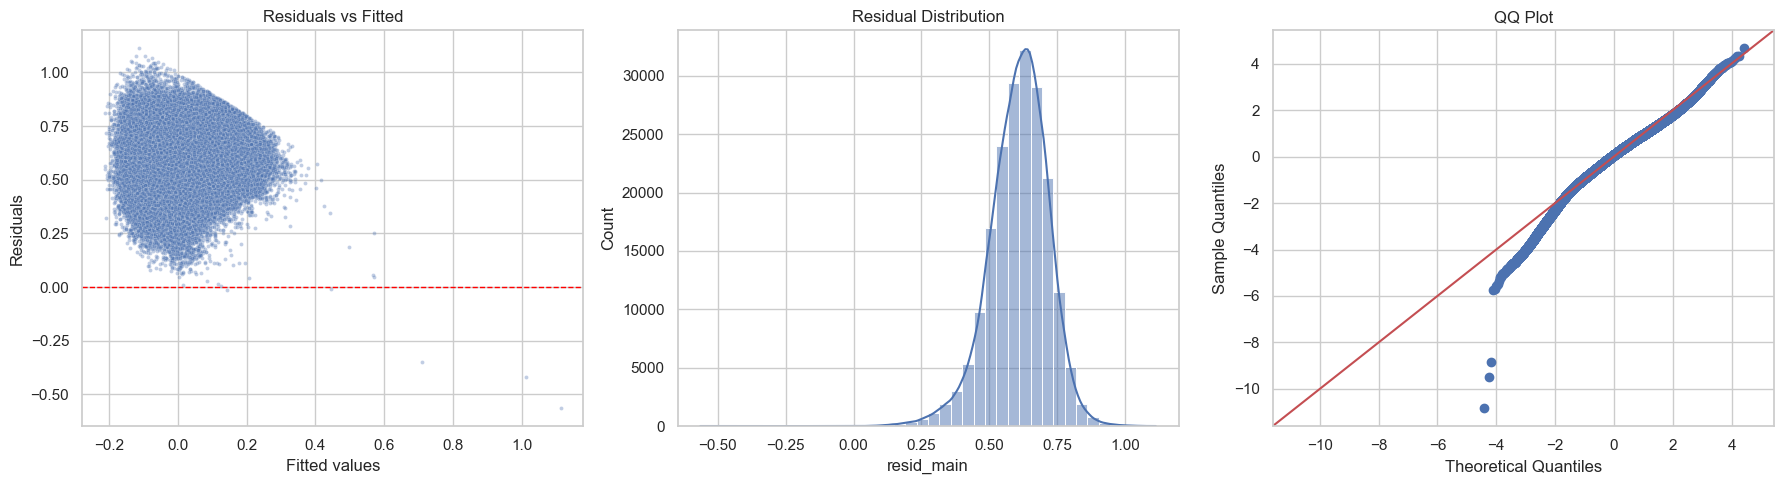

In [48]:
fitted_main, resid_main, prediction_type = safe_mixedlm_predictions(
    main_result,
    y=df_ml[target].values
)

df_ml['fitted_main'] = fitted_main
df_ml['resid_main'] = resid_main

print('Prediction type used for diagnostics:', prediction_type)
if prediction_type == 'fixed_only_singular_random_effects':
    print('Random-effect covariance was singular, so diagnostics use fixed-effect predictions only.')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df_ml, x='fitted_main', y='resid_main', s=8, alpha=0.35, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')

sns.histplot(df_ml['resid_main'], bins=40, kde=True, ax=axes[1])
axes[1].set_title('Residual Distribution')

sm.qqplot(df_ml['resid_main'], line='45', fit=True, ax=axes[2])
axes[2].set_title('QQ Plot')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/main_model_residual_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

,n,observed_mean,fitted_mean,residual_mean,residual_sd
City,,,,,
Shenyang,6573,0.5627,0.0514,0.5113,0.1220
Harbin,5327,0.5779,0.0514,0.5264,0.1130
Beijing,14617,0.5889,0.0514,0.5375,0.0824
Shijiazhuang,2941,0.5964,0.0514,0.5450,0.0761
Dalian,5603,0.5983,0.0514,0.5469,0.1095
Tianjin,12170,0.6023,0.0514,0.5509,0.1034
Urumqi,5413,0.6058,0.0514,0.5543,0.1332
Jinan,6886,0.6184,0.0514,0.5670,0.1049
Xining,1542,0.6208,0.0514,0.5693,0.1119


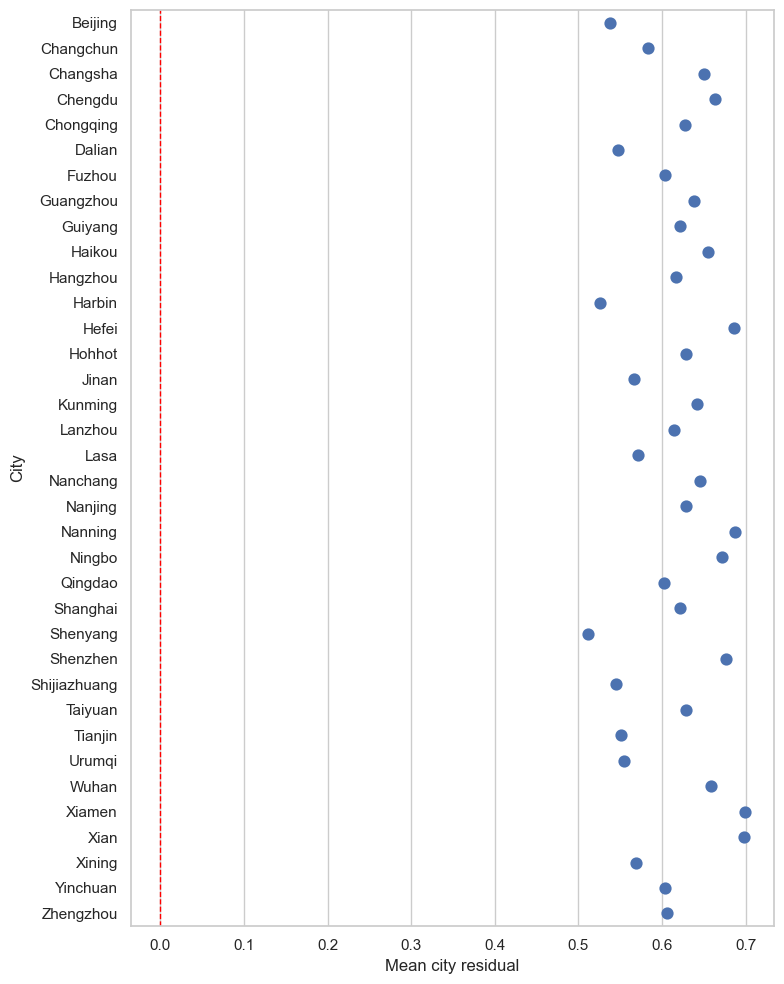

In [49]:
city_residuals = (
    df_ml.groupby(group_col)
    .agg(
        n=(target, 'size'),
        observed_mean=(target, 'mean'),
        fitted_mean=('fitted_main', 'mean'),
        residual_mean=('resid_main', 'mean'),
        residual_sd=('resid_main', 'std')
    )
    .sort_values('residual_mean')
)

city_residuals.to_csv(f'{OUT_DIR}/city_level_residuals.csv')
display(city_residuals)

plt.figure(figsize=(8, 10))
sns.pointplot(
    data=city_residuals.reset_index(),
    x='residual_mean',
    y=group_col,
    join=False
)
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Mean city residual')
plt.ylabel('City')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/city_mean_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. City Random-Slope Model and Slope Plots

Random slopes are useful only for a small number of theoretically important predictors. This section automatically selects variables that are both statistically significant in the main within-city model and common in urban planning. It then plots city-specific slopes where the random-slope model can be estimated.

Random-slope plotting features: ['SVF', 'roadDensity', 'intersectionDensity']

Fitting city random-slope model for selected planning variables:
performance_score ~ buildingCount_w_z + compactness_w_z + footprintAreaTotal_w_z + avgBuildingArea_w_z + roadDensity_w_z + intersectionDensity_w_z + poiDensity_w_z + poiDiversity_w_z + FVC_w_z + permeableRatio_w_z + maxHeight_w_z + minHeight_w_z + heightIndex_w_z + heightOtherness_w_z + basePerimeterMax_w_z + basePerimeterMin_w_z + shapeComplexity_w_z + areaVariance_w_z + parcelArea_w_z + largestPatchIndex_w_z + shape3DIndex_w_z + evennessIndex_w_z + cornerCountAvg_w_z + buildingMinDist_w_z + buildingDistVar_w_z + SVF_w_z + streetRatio_w_z
                          Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         performance_score
No. Observations:           194941          Method:                     ML               
No. Groups:                 36              Scale:                

,marginal_R2_fixed_only,conditional_R2_fixed_plus_random,var_fixed,var_random,var_residual
0,0.3920,0.5513,0.0077,0.0031,0.0088


,term,coef,std_err,z_value,p_value,significant_0_05
0,Intercept,0.6664,0.0084,79.6387,0.0000,True
13,heightIndex_w_z,-0.0157,0.0003,-51.1142,0.0000,True
9,FVC_w_z,-0.0094,0.0002,-40.3616,0.0000,True
8,poiDiversity_w_z,0.0104,0.0003,38.1666,0.0000,True
20,largestPatchIndex_w_z,-0.0239,0.0004,-62.0347,0.0000,True
19,parcelArea_w_z,0.0424,0.0004,99.4475,0.0000,True
17,shapeComplexity_w_z,0.0129,0.0004,31.0459,0.0000,True
11,maxHeight_w_z,0.0119,0.0004,28.9628,0.0000,True
2,compactness_w_z,0.0072,0.0004,20.1143,0.0000,True
14,heightOtherness_w_z,0.0062,0.0004,17.5871,0.0000,True


,City,term,feature,fixed_slope,city_random_slope_deviation,city_specific_slope
0,Beijing,SVF_w_z,SVF,-0.0124,0.0018,-0.0105
1,Beijing,roadDensity_w_z,roadDensity,0.0086,-0.0012,0.0074
2,Beijing,intersectionDensity_w_z,intersectionDensity,0.0211,-0.0135,0.0076
3,Changchun,SVF_w_z,SVF,-0.0124,-0.0022,-0.0146
4,Changchun,roadDensity_w_z,roadDensity,0.0086,0.0036,0.0122


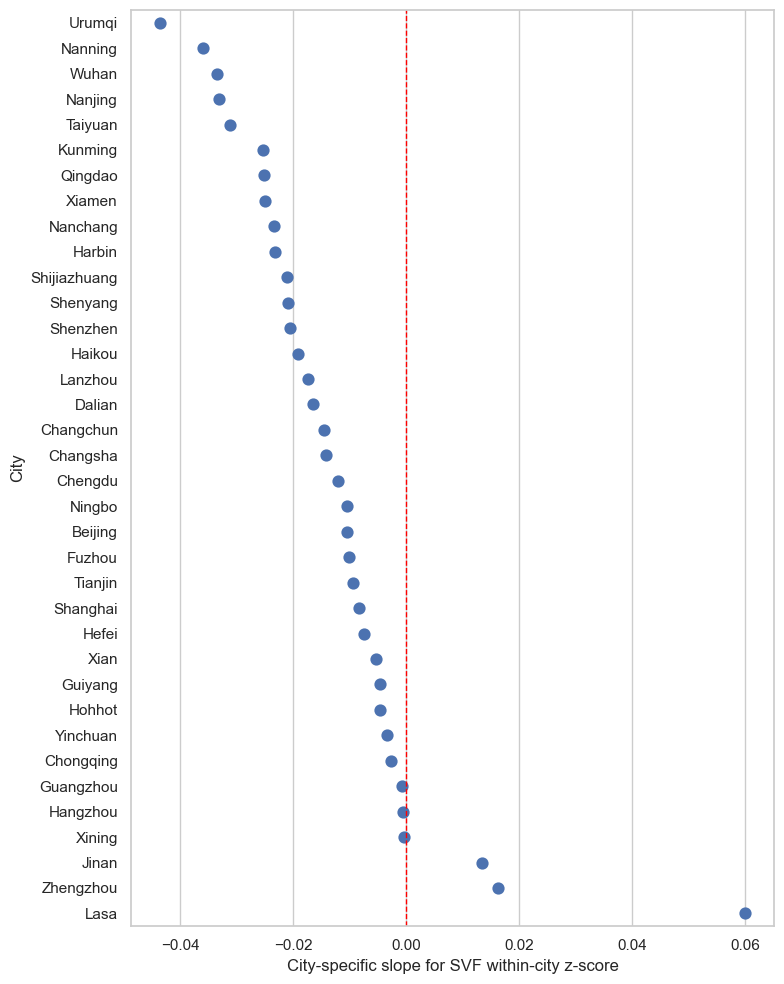

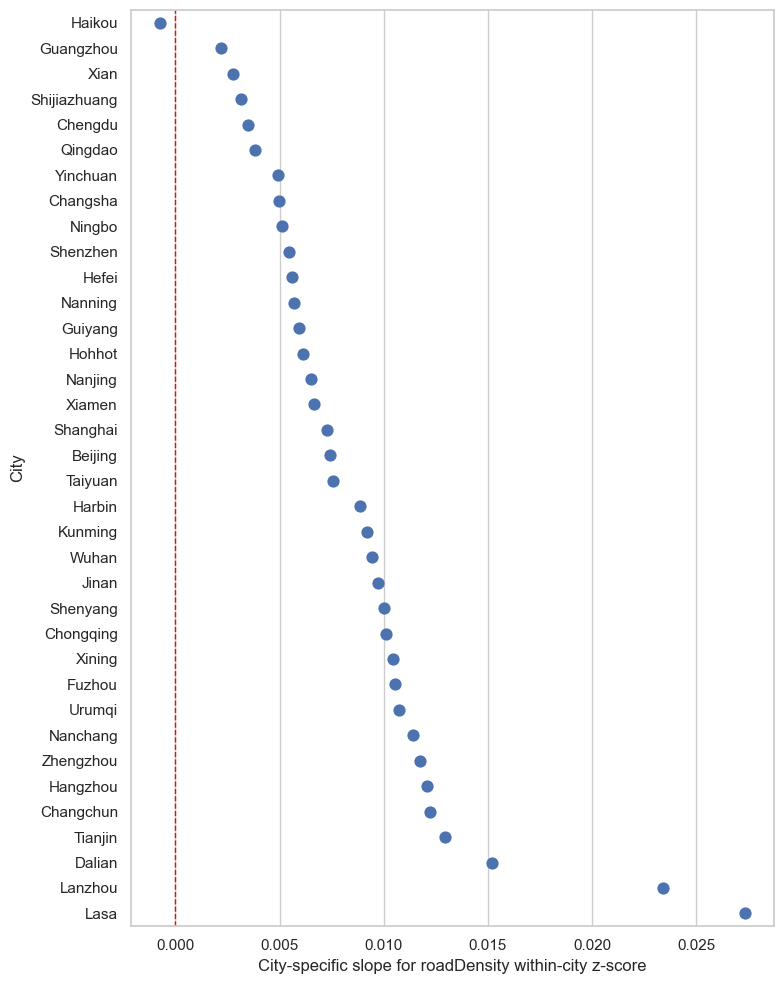

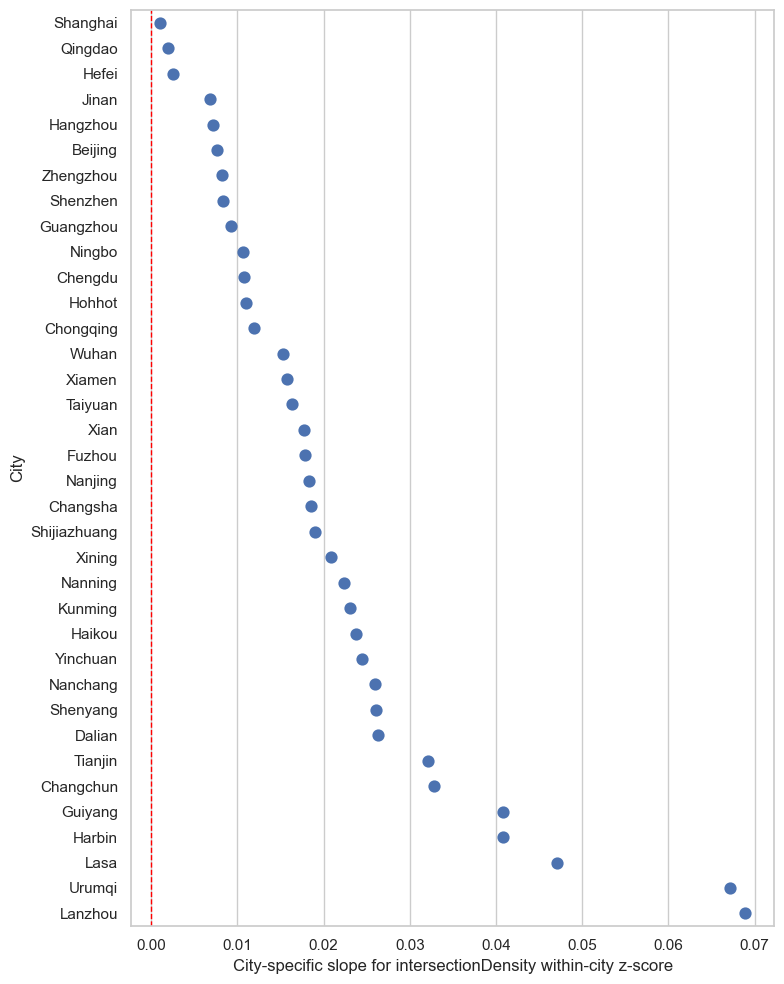

In [50]:
RUN_RANDOM_SLOPE_MODEL = True
MAX_RANDOM_SLOPE_FEATURES = 3

planning_priority = [
    'FAR', 'coverageRatio', 'SVF', 'roadDensity', 'intersectionDensity',
    'buildingCount', 'avgHeight', 'FVC', 'permeableRatio', 'compactness'
]

main_feature_names = [term.replace('_w_z', '') for term in within_terms_pruned]
significant_within_terms = main_coef.loc[
    (main_coef['p_value'] < 0.05) & (main_coef['term'].isin(within_terms_pruned)),
    'term'
].tolist()
significant_planning_features = [
    f for f in planning_priority
    if f in main_feature_names and f'{f}_w_z' in significant_within_terms
]

# If no planning-priority variable is significant, plot the first surviving planning variables as exploratory checks.
if len(significant_planning_features) == 0:
    significant_planning_features = [f for f in planning_priority if f in main_feature_names]

random_slope_features = significant_planning_features[:MAX_RANDOM_SLOPE_FEATURES]
print('Random-slope plotting features:', random_slope_features)

if RUN_RANDOM_SLOPE_MODEL and len(random_slope_features) > 0:
    random_slope_terms = [f'{f}_w_z' for f in random_slope_features]
    random_slope_formula = '1 + ' + ' + '.join(random_slope_terms)

    try:
        slope_result = fit_mixedlm(
            formula=main_formula,
            data=df_ml,
            group_col=group_col,
            re_formula=random_slope_formula,
            model_name='city random-slope model for selected planning variables'
        )

        slope_coef = coefficient_table(slope_result)
        slope_r2 = pd.DataFrame([mixedlm_r2(slope_result)])

        slope_coef.to_csv(f'{OUT_DIR}/city_random_slope_coefficients.csv', index=False)
        slope_r2.to_csv(f'{OUT_DIR}/city_random_slope_r2.csv', index=False)

        with open(f'{OUT_DIR}/city_random_slope_summary.txt', 'w', encoding='utf-8') as f:
            f.write(slope_result.summary().as_text())

        display(slope_r2)
        display(slope_coef.head(30))

        random_effect_rows = []
        random_effects = slope_result.random_effects

        for city, effects in random_effects.items():
            for term in random_slope_terms:
                fixed_slope = slope_result.fe_params.get(term, np.nan)
                random_slope = effects.get(term, 0.0)
                random_effect_rows.append({
                    'City': city,
                    'term': term,
                    'feature': term.replace('_w_z', ''),
                    'fixed_slope': fixed_slope,
                    'city_random_slope_deviation': random_slope,
                    'city_specific_slope': fixed_slope + random_slope
                })

        city_slopes = pd.DataFrame(random_effect_rows)
        city_slopes.to_csv(f'{OUT_DIR}/city_specific_random_slopes.csv', index=False)
        display(city_slopes.head())

        for feature in random_slope_features:
            plot_df = city_slopes[city_slopes['feature'] == feature].sort_values('city_specific_slope')

            plt.figure(figsize=(8, 10))
            sns.pointplot(
                data=plot_df,
                x='city_specific_slope',
                y='City',
                join=False
            )
            plt.axvline(0, color='red', linestyle='--', linewidth=1)
            plt.xlabel(f'City-specific slope for {feature} within-city z-score')
            plt.ylabel('City')
            plt.tight_layout()
            plt.savefig(f'{OUT_DIR}/city_random_slopes_{feature}.png', dpi=300, bbox_inches='tight')
            plt.show()

    except Exception as err:
        print('Random-slope model or plotting failed:')
        print(err)
        print('This usually means the selected random-slope structure is too complex or singular for the data.')
else:
    print('Random-slope model skipped because no selected planning variables survived screening.')

## 13. Optional Full-Feature Sensitivity Model

This model uses all original predictors after standardization. It is provided only as a sensitivity check because multicollinearity can make coefficients unstable.

In [51]:
RUN_FULL_FEATURE_SENSITIVITY = False

if RUN_FULL_FEATURE_SENSITIVITY:
    df_full = df.copy()
    full_z_terms = [f'{f}_z' for f in features]
    df_full[full_z_terms] = StandardScaler().fit_transform(df_full[features])

    full_terms = full_z_terms.copy()
    if USE_CITY_CATEGORY:
        full_terms.append('C(City_Category)')

    full_formula = f"{target} ~ " + " + ".join(full_terms)

    full_result = fit_mixedlm(
        formula=full_formula,
        data=df_full,
        group_col=group_col,
        model_name='full-feature sensitivity model'
    )

    full_coef = coefficient_table(full_result)
    full_r2 = pd.DataFrame([mixedlm_r2(full_result)])

    full_coef.to_csv(f'{OUT_DIR}/full_feature_sensitivity_coefficients.csv', index=False)
    full_r2.to_csv(f'{OUT_DIR}/full_feature_sensitivity_r2.csv', index=False)

    with open(f'{OUT_DIR}/full_feature_sensitivity_summary.txt', 'w', encoding='utf-8') as f:
        f.write(full_result.summary().as_text())

    display(full_r2)
    display(full_coef.head(30))
else:
    print("Full-feature sensitivity model skipped. Set RUN_FULL_FEATURE_SENSITIVITY = True to run it.")

Full-feature sensitivity model skipped. Set RUN_FULL_FEATURE_SENSITIVITY = True to run it.


## Interpretation Notes

- Use the **within-city coefficients** to discuss how grid cells differ inside the same city.
- Use the **between-city coefficients** to discuss how city-average urban form relates to city-average performance.
- Avoid interpreting the full 40-feature model as feature importance because many variables measure overlapping constructs.
- Because `performance_score` is a constructed bounded index, treat the model as associational, not causal.
- Use the city random-slope plots only as evidence of context-dependent effects when the random-slope model converges and the slope variance is not singular.